In [2]:
import pandas as pd

files = [
    r"/Users/harp/Desktop/Capstone project/Dataset/2020_01.csv",
    r"/Users/harp/Desktop/Capstone project/Dataset/2020_02.csv",
    r"/Users/harp/Desktop/Capstone project/Dataset/2020_03.csv",
    r"/Users/harp/Desktop/Capstone project/Dataset/2020_04.csv",
    r"/Users/harp/Desktop/Capstone project/Dataset/2020_05.csv"
]

dfs = [pd.read_csv(file) for file in files]

OTP_df = pd.concat(dfs, ignore_index=True)

print("Merged Dataset Shape:", OTP_df.shape)

OTP_df.head()

Merged Dataset Shape: (965568, 13)


,date,train_id,stop_sequence,from,from_id,to,to_id,scheduled_time,actual_time,delay_minutes,status,line,type
0,2020-01-01,0539,1.0,Hoboken,63.0,Hoboken,63.0,2020-01-01 20:08:00,2020-01-01 20:09:11,1.183333,departed,Montclair-Boonton,NJ Transit
1,2020-01-01,0539,2.0,Hoboken,63.0,Newark Broad Street,106.0,2020-01-01 20:26:00,2020-01-01 20:31:03,5.050000,departed,Montclair-Boonton,NJ Transit
2,2020-01-01,0539,3.0,Newark Broad Street,106.0,Watsessing Avenue,154.0,2020-01-01 20:38:00,2020-01-01 20:40:26,2.433333,departed,Montclair-Boonton,NJ Transit
3,2020-01-01,0539,4.0,Watsessing Avenue,154.0,Bloomfield,19.0,2020-01-01 20:40:00,2020-01-01 20:42:04,2.066667,departed,Montclair-Boonton,NJ Transit
4,2020-01-01,0539,5.0,Bloomfield,19.0,Glen Ridge,50.0,2020-01-01 20:43:00,2020-01-01 20:46:12,3.200000,departed,Montclair-Boonton,NJ Transit


Data from Jan - May 2020 were combined into a single dataset using pd.Concat()
With each row representing the train stop event containing scheduled and actual operating times, station information, operator and delay duration

In [3]:
OTP_df.to_csv("OTP_df.csv", index=False)

print("Merged file saved as merged_dataset.csv")

Merged file saved as merged_dataset.csv


In [4]:
#Inspecting the Dataset
OTP_df.describe()

,stop_sequence,from_id,to_id,delay_minutes
count,870025.000000,965565.000000,965565.000000,870025.000000
mean,8.058393,4208.960811,4218.754018,3.761713
std,5.053450,11793.927215,11805.239950,8.532076
min,1.000000,1.000000,1.000000,0.000000
25%,4.000000,52.000000,52.000000,0.366667
50%,7.000000,103.000000,103.000000,2.083333
75%,11.000000,136.000000,136.000000,4.066667
max,26.000000,43599.000000,43599.000000,406.000000


In [5]:
#For categorical
OTP_df.describe(include='object')

,date,train_id,from,to,scheduled_time,actual_time,status,line,type
count,965568,965568,965568,965568,870025,965568,965568,965568,965568
unique,139,1545,165,165,172401,653935,3,30,2
top,2020-01-17,0070,New York Penn Station,New York Penn Station,2020-03-04 18:04:00,2020-05-04 05:37:11,departed,Morristown Line,NJ Transit
freq,9785,2100,38932,39142,19,28,870713,153241,924898


In [59]:
"""# Install (run once)
!pip install -q ydata-profiling sweetviz

# Import
from ydata_profiling import ProfileReport

# Create report
profile = ProfileReport(
    OTP_df,
    title="Merged Dataset Profiling Report",
    explorative=True
)

# Save report
profile.to_file("ydata_profile_report.html")

print("Report saved successfully as 'ydata_profile_report.html'")"""

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████| 13/13 [00:07<00:00,  1.71it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report saved successfully as 'ydata_profile_report.html'


In [60]:
import sweetviz as sv
report = sv.analyze(OTP_df)
report.show_html( "sweetviz_report.html")
print("Sweetviz report generated.")

#To download the sweetviz report
#files.download("sweetviz_report.html")

                                             |      | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Sweetviz report generated.


In [13]:
#Initial Data quality
missing = OTP_df.isnull().sum()
missing = (missing.sort_values(ascending=False))

#Visual representation
missing.plot.bar()

#Missing Percentage
missing_percent = OTP_df.isnull().mean()*100

missing_table = pd.DataFrame({
    "Missing Values":missing,
    "Percentage":missing_percent.round(2)
})

missing_table

,Missing Values,Percentage
actual_time,0,0.0
date,0,0.0
delay_minutes,95543,9.9
from,0,0.0
from_id,3,0.0
line,0,0.0
scheduled_time,95543,9.9
status,0,0.0
stop_sequence,95543,9.9
to,0,0.0


In [14]:
#Duplicate rows check
duplicates= OTP_df.duplicated().sum()
duplicates
#Removing the duplicate rows
OTP_df.drop_duplicates(inplace=True)

Duplicate observations were removed, if any present in the dataset.

In [15]:
#Data Consistency Check
OTP_df["type"].unique()
OTP_df["line"].unique()
categorical = [
    "status",
    "line",
    "type",
    "from",
    "to"
]

for col in categorical:

    print("\n",col)

    print(OTP_df[col].nunique())

    print(OTP_df[col].unique()[:15])


 status
3
['departed' 'estimated' 'cancelled']

 line
30
['Montclair-Boonton' 'KEYSTONE' 'Bergen Co. Line ' 'PENNSYLVANIAN'
 'No Jersey Coast' 'Amtrak' 'Main Line' 'CRESCENT' 'REGIONAL' 'CAROLINIAN'
 'Morristown Line' 'Northeast Corrdr' 'Raritan Valley' 'Princeton Shuttle'
 'ACELA EXPRESS']

 type
2
['NJ Transit' 'Amtrak']

 from
165
['Hoboken' 'Newark Broad Street' 'Watsessing Avenue' 'Bloomfield'
 'Glen Ridge' 'New York Penn Station' 'Newark Penn Station' 'Trenton'
 'Waldwick' 'Ridgewood' 'Glen Rock Boro Hall' 'Radburn Fair Lawn'
 'Broadway Fair Lawn' 'Plauderville' 'Garfield']

 to
165
['Hoboken' 'Newark Broad Street' 'Watsessing Avenue' 'Bloomfield'
 'Glen Ridge' 'Bay Street' 'New York Penn Station' 'Newark Penn Station'
 'Trenton' 'Philadelphia' 'Waldwick' 'Ridgewood' 'Glen Rock Boro Hall'
 'Radburn Fair Lawn' 'Broadway Fair Lawn']


In [16]:
#TIMESTAMP-PARSING- Convert time columns
OTP_df['scheduled_time'] = pd.to_datetime(OTP_df['scheduled_time'])
OTP_df['actual_time'] = pd.to_datetime(OTP_df['actual_time'])
OTP_df['date'] = pd.to_datetime(OTP_df['date'])

OTP_df.dtypes

date              datetime64[ns]
train_id                  object
stop_sequence            float64
from                      object
from_id                  float64
to                        object
to_id                    float64
scheduled_time    datetime64[ns]
actual_time       datetime64[ns]
delay_minutes            float64
status                    object
line                      object
type                      object
dtype: object

Timestamp Variable were converted to datetime format to enable extraction of temporal features including hour, weekday and month.

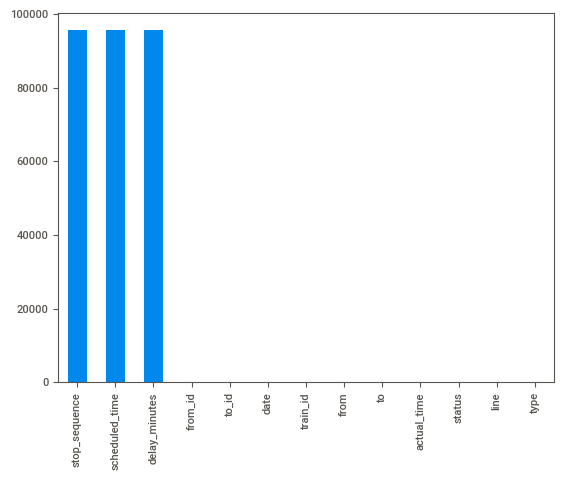

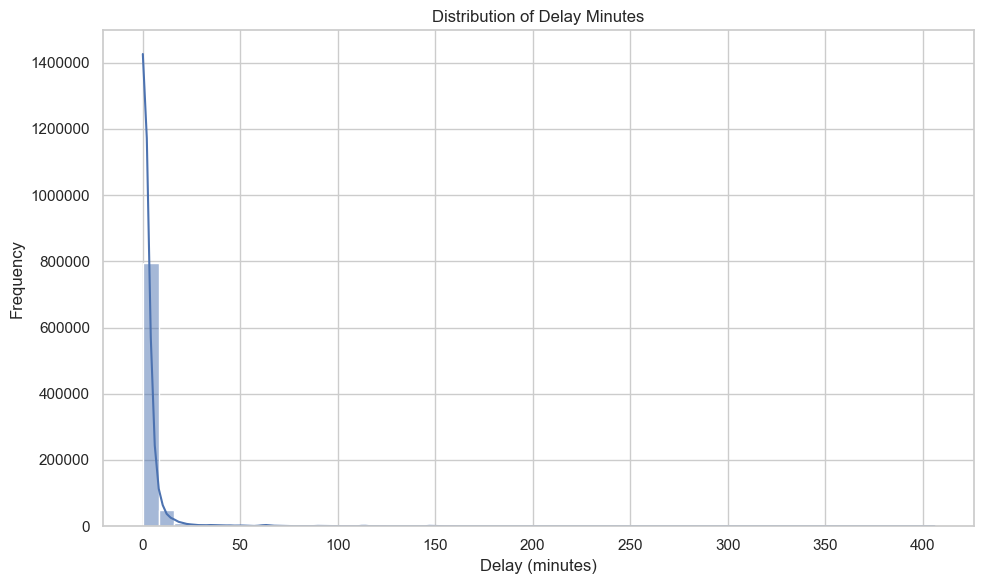

In [17]:
# Display plots inside the notebook
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style (optional)
sns.set_theme(style="whitegrid")

# Delay Distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    OTP_df["delay_minutes"].dropna(),  # Remove missing values
    bins=50,
    kde=True
)

plt.title("Distribution of Delay Minutes")
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


Delay minutes exhibit a positively skewed distribution with a long right tail, indicating that while most train experience minimal delays, a small number experience substancial operational disruptions. This supports the use of median imputation and robust statistical methods.

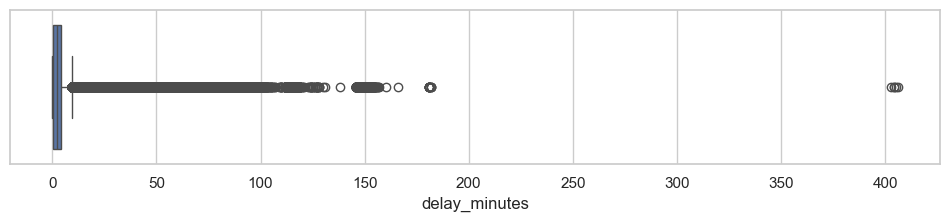

In [18]:
#Boxplot
plt.figure(figsize=(12,2))

sns.boxplot(
    x=OTP_df["delay_minutes"]
)

plt.show()

Extreme delay observations were identified using boxplot. These values were retained because they represent genuine disruption events rather than measurement errors.

In [19]:
#MISSING VALUE TREATMENT
OTP_df['delay_minutes'] = OTP_df['delay_minutes'].fillna(
    OTP_df['delay_minutes'].median()
)

OTP_df['status'] = OTP_df['status'].fillna('Unknown')
OTP_df['line'] = OTP_df['line'].fillna('Unknown')

In [20]:
import numpy as np
#Correlation for numeric Variables
numeric = OTP_df.select_dtypes(
    include=np.number
)

numeric.corr()

,stop_sequence,from_id,to_id,delay_minutes
stop_sequence,1.000000,0.031703,-0.025489,-0.011766
from_id,0.031703,1.000000,-0.092192,-0.010394
to_id,-0.025489,-0.092192,1.000000,0.010880
delay_minutes,-0.011766,-0.010394,0.010880,1.000000


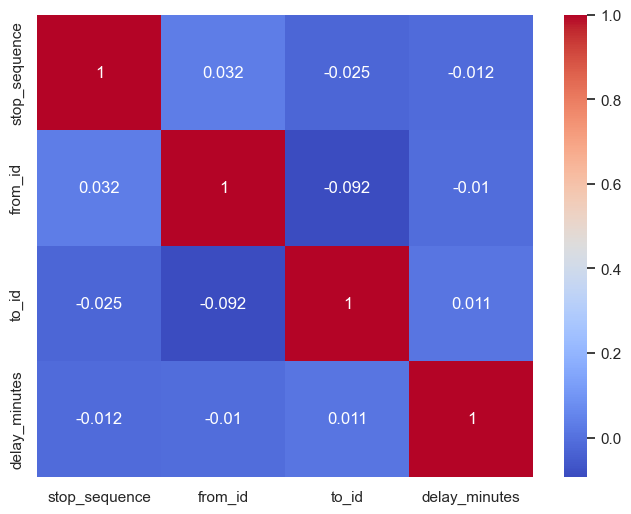

In [21]:
#Correlation plot
plt.figure(figsize=(8,6))
sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [22]:
#Saving clean dataset
OTP_df.to_csv(
    "combined_dataset.csv",
    index=False
)

In [23]:
#Creating a copy of clean dataset for feature engineering
OTP_Copy=OTP_df.copy()

In [24]:
#Verifying Date and time columns
print(OTP_Copy[['date','scheduled_time','actual_time']].dtypes)

date              datetime64[ns]
scheduled_time    datetime64[ns]
actual_time       datetime64[ns]
dtype: object


Hour feature captures the scheduled operating hour and allows the identification of peak congestion period.

In [25]:
#FEATURE ENGINEERING

#Extracting hour from the scheduled time
OTP_Copy['hour'] = OTP_Copy['scheduled_time'].dt.hour
OTP_Copy[["scheduled_time","hour"]].tail()

,scheduled_time,hour
965563,2020-05-18 17:16:00,17.0
965564,2020-05-18 17:21:00,17.0
965565,2020-05-18 17:24:00,17.0
965566,2020-05-18 17:30:00,17.0
965567,2020-05-18 17:42:00,17.0




*   Day of week: Different weekday can have different passenger demand.
*   Month: Used for seasonal trend analysis
*   Saturday=5, Sunday= 6
*   rush_hour flag:  1 - rush hour & 0 - outside of rush hour.
Rush hour correspond to peak commuter demand and are expected to have higher delay frequency. Morning Rush hour from 0700-1000 hours and Afternoon from 1600-1900 hours.

*   Season will depends on the month that is:
  Dec, Jan , Feb: Winter
  March, April , May: Spring
  June, July , August: Summer
  Sept, Oct, Nov: Fall
*   OTP_Binary : If delay is less than equal to 5 minutes than it will return 1 else 0. OTP Indicator was created using the industry threshold of five minutes.







In [26]:
#Similarly extracting Day of the week, month, weekend, Rush Hour, Season, OTP (1,0)
OTP_Copy['day_of_week'] = OTP_Copy['date'].dt.day_name()

OTP_Copy['month'] = OTP_Copy['date'].dt.month

OTP_Copy["weekend"] = np.where(OTP_Copy["date"].dt.dayofweek >=5,1,0)

OTP_Copy["rush_hour"] = np.where(
    ((OTP_Copy["hour"]>=7)&(OTP_Copy["hour"]<=10))|
    ((OTP_Copy["hour"]>=16)&(OTP_Copy["hour"]<=19)),
    1,
    0
)

def season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

OTP_Copy["season"] = OTP_Copy["month"].apply(season)

OTP_Copy["otp_binary"] = np.where(
    OTP_Copy["delay_minutes"]<=5,
    1,
    0
)

OTP_Copy[["date","day_of_week","month","weekend","rush_hour","season","otp_binary"]].head()

,date,day_of_week,month,weekend,rush_hour,season,otp_binary
0,2020-01-01,Wednesday,1,0,0,Winter,1
1,2020-01-01,Wednesday,1,0,0,Winter,0
2,2020-01-01,Wednesday,1,0,0,Winter,1
3,2020-01-01,Wednesday,1,0,0,Winter,1
4,2020-01-01,Wednesday,1,0,0,Winter,1


**Average Station Delay**
Represents the histotical delay experience at each station.

In [27]:
#STATION RELIABILITY- Highest average delay most unreliable

station_delay = OTP_Copy .groupby("from")["delay_minutes"].mean()
OTP_Copy["avg_station_delay"] = ( OTP_Copy["from"].map(station_delay))
OTP_Copy[["from", "avg_station_delay"]].sort_values(by="avg_station_delay",
ascending=False).sample(10)

,from,avg_station_delay
431147,Middletown NJ,3.836513
606050,Newark Airport,3.060358
394210,Hoboken,2.812073
758155,Newark Airport,3.060358
351918,South Orange,3.522633
226589,Newark Penn Station,3.151434
683784,Princeton,0.700060
791176,Red Bank,4.155992
798777,Orange,3.302994
625267,Montclair State U,2.437649


**ROUTE DELAY FREQUENCY**


In [28]:
#Creating the delay frequency
route_frequency = (OTP_Copy.groupby("line")["delay_minutes"].count())

#Merging with the dataset
OTP_Copy["route_delay_frequency"] = (OTP_Copy["line"].map(route_frequency))
OTP_Copy[["line", "route_delay_frequency"]].sort_values(by="route_delay_frequency",ascending=False).sample(10)

,line,route_delay_frequency
115702,Morristown Line,153241
926790,Morristown Line,153241
784933,Pascack Valley,59708
584711,Pascack Valley,59708
95712,Raritan Valley,80413
430170,Morristown Line,153241
384118,Northeast Corrdr,145825
265269,No Jersey Coast,150754
740775,No Jersey Coast,150754
543967,Morristown Line,153241


In [29]:
#Historical Route reliability: How reliable this line historically is
route_reliability = (OTP_Copy.groupby("line")["otp_binary"].mean())
OTP_Copy["historical_route_reliability"] = (OTP_Copy["line"].map(route_reliability))

OTP_Copy[["line", "historical_route_reliability"]].sort_values(by="historical_route_reliability",
ascending=False).head()

,line,historical_route_reliability
752214,REGIONAL,1.0
553503,ACELA EXPRESS,1.0
30150,REGIONAL,1.0
30151,REGIONAL,1.0
30152,REGIONAL,1.0


In [30]:
#OPERATOR COMPARISON
OTP_Copy.groupby('type')['delay_minutes'].agg(['mean','median','std'])

,mean,median,std
type,,,
Amtrak,2.083333,2.083333,0.000000
NJ Transit,3.662137,2.083333,8.284601


In [31]:
#Verifying new features

new_features = [

"hour",

"day_of_week",

"month",

"weekend",

"rush_hour",

"season",

"otp_binary",

"avg_station_delay",

"route_delay_frequency",

"historical_route_reliability"

]

OTP_Copy[new_features].head()

,hour,day_of_week,month,weekend,rush_hour,season,otp_binary,avg_station_delay,route_delay_frequency,historical_route_reliability
0,20.0,Wednesday,1,0,0,Winter,1,2.812073,65923,0.755745
1,20.0,Wednesday,1,0,0,Winter,0,2.812073,65923,0.755745
2,20.0,Wednesday,1,0,0,Winter,1,3.960791,65923,0.755745
3,20.0,Wednesday,1,0,0,Winter,1,6.830793,65923,0.755745
4,20.0,Wednesday,1,0,0,Winter,1,5.327146,65923,0.755745


In [32]:
#Save feature engineered dataset
OTP_Copy.to_csv(
    "feature_engineered_dataset.csv",
    index=False
)

In [33]:
print("Dataset Shape:", OTP_Copy.shape)
print("\nColumns")
print(OTP_Copy.columns)
print("\nData Types")
print(OTP_Copy.dtypes)

Dataset Shape: (965568, 23)

Columns
Index(['date', 'train_id', 'stop_sequence', 'from', 'from_id', 'to', 'to_id',
       'scheduled_time', 'actual_time', 'delay_minutes', 'status', 'line',
       'type', 'hour', 'day_of_week', 'month', 'weekend', 'rush_hour',
       'season', 'otp_binary', 'avg_station_delay', 'route_delay_frequency',
       'historical_route_reliability'],
      dtype='object')

Data Types
date                            datetime64[ns]
train_id                                object
stop_sequence                          float64
from                                    object
from_id                                float64
to                                      object
to_id                                  float64
scheduled_time                  datetime64[ns]
actual_time                     datetime64[ns]
delay_minutes                          float64
status                                  object
line                                    object
type                    

=====================================================================================================================

**RESEARCH QUESTIONS**


***STATION RELIABILITY***

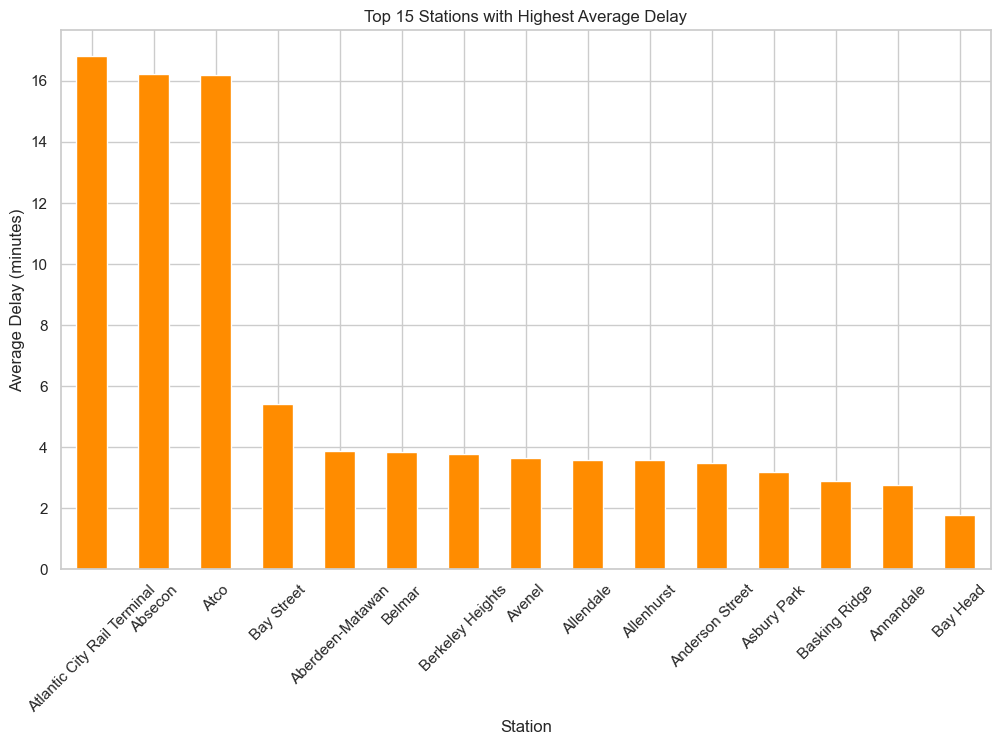

In [34]:
plt.figure(figsize=(12,7))

station_delay.head(15).sort_values(ascending=False).plot(
    kind="bar",
    color="darkorange"
)

plt.ylabel("Average Delay (minutes)")

plt.xlabel("Station")

plt.title("Top 15 Stations with Highest Average Delay")

plt.xticks(rotation=45)

plt.show()

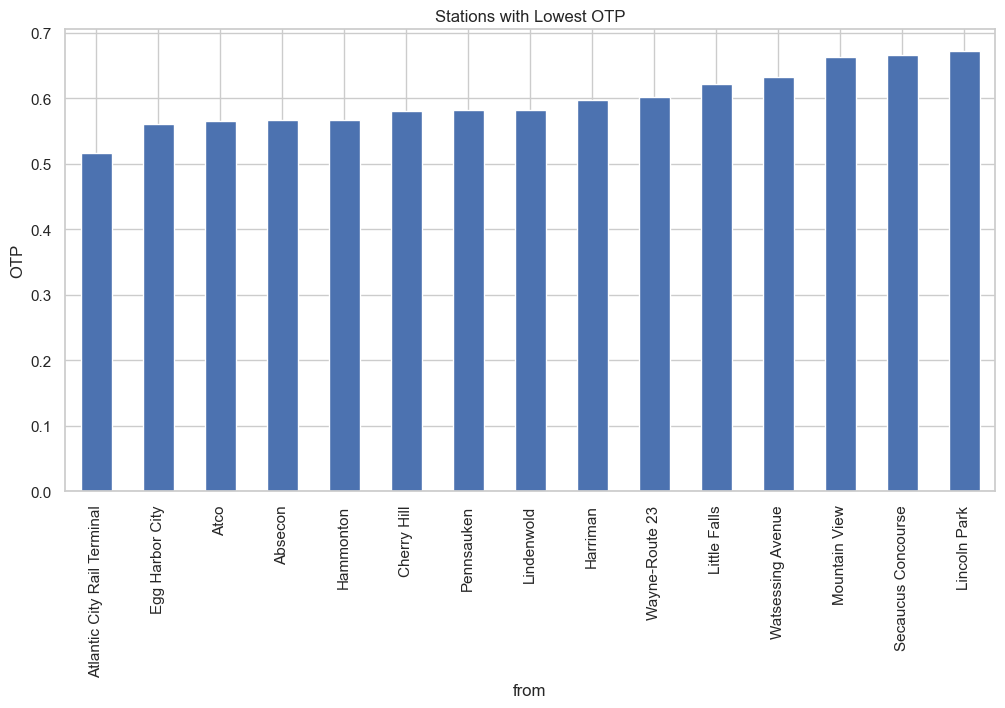

In [35]:
station_otp = (OTP_Copy
.groupby("from")["otp_binary"].mean().sort_values())
plt.figure(figsize=(12,6))
station_otp.head(15).sort_values(ascending=True).plot.bar()
plt.ylabel("OTP")
plt.title("Stations with Lowest OTP")
plt.show()

Station reliability is analyzed by calculating average delay minutes and on-time performance by station. Stations with higher average delays may indicate operational bottlenecks, congestion points, or infrastructure-related inefficiencies. Stations with lower OTP values represent locations where trains were less consistently on time

***ROUTE RELIABILTIY***

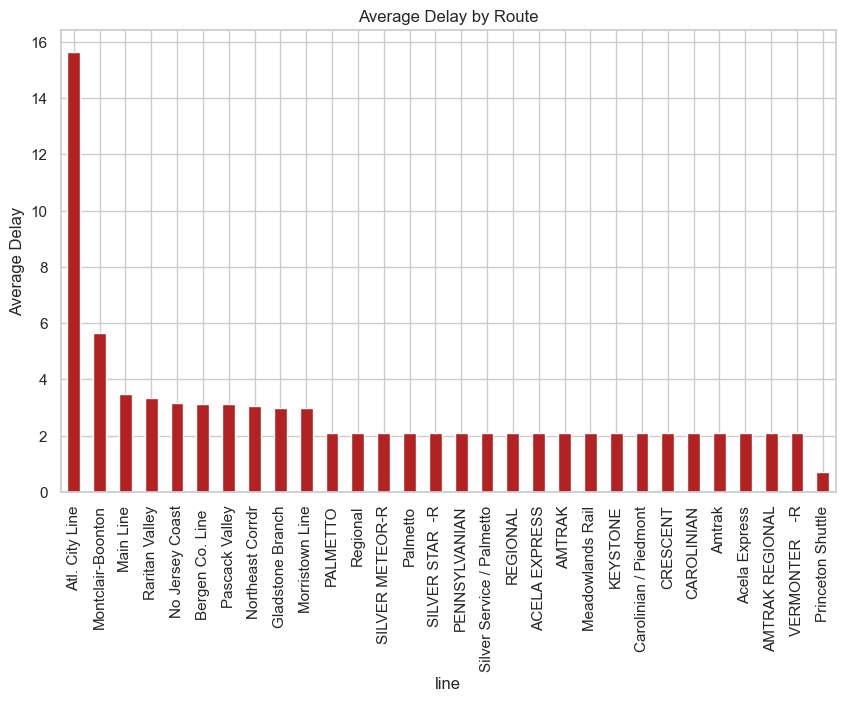

In [36]:
route_delay = (
OTP_Copy
.groupby("line")
["delay_minutes"]
.mean()
.sort_values(
ascending=False
)
)

plt.figure(figsize=(10,6))
route_delay.plot.bar(
color="firebrick")
plt.ylabel("Average Delay")
plt.title("Average Delay by Route")
plt.show()

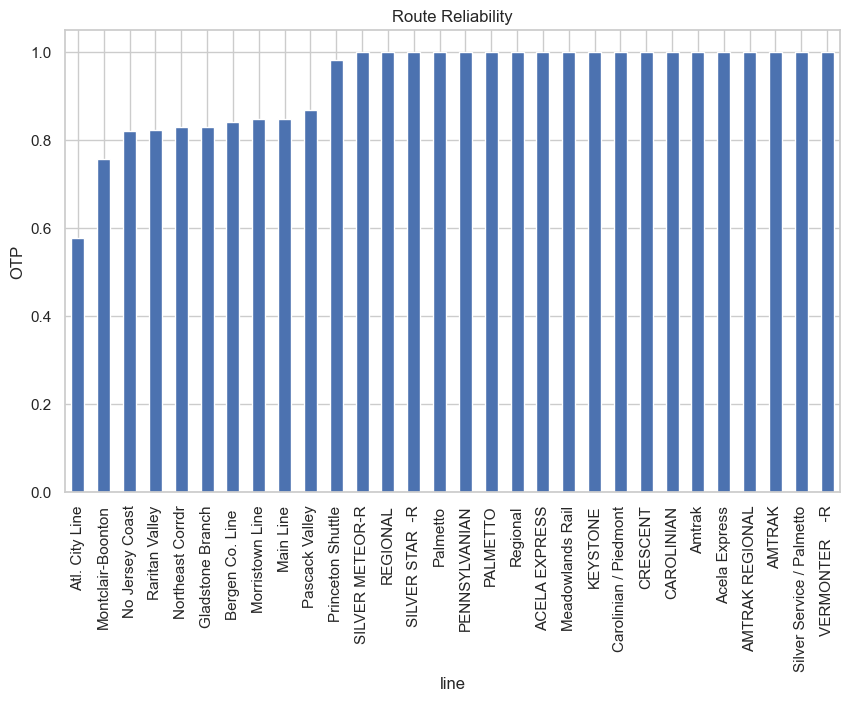

In [37]:
#Route OTP
route_otp = (
OTP_Copy
.groupby("line")
["otp_binary"]
.mean()
.sort_values()
)
plt.figure(figsize=(10,6))
route_otp.plot.bar()
plt.ylabel("OTP")
plt.title("Route Reliability")
plt.show()

Route reliability is analyzed by grouping data by line. This helped compare average delay and OTP across different routes. Routes with higher average delay and lower OTP can be considered less reliable. This directly answers whether certain routes perform worse than others in terms of punctuality.

**TEMPORAL DELAY PATTERNS**
Temporal delay patterns are analyzed using hour, day of week, weekend, month, and rush-hour features.
*   The hourly delay trend helped identify whether delays increased during certain times of day.
*   The rush-hour variable allowed comparison between peak and non-peak periods.
*   Day-of-week analysis helped identify whether certain weekdays or weekends experienced higher delay levels.
*   Monthly and seasonal analysis helped observe whether delay patterns changed from January through May.

**HOURLY DELAY PATTERN**

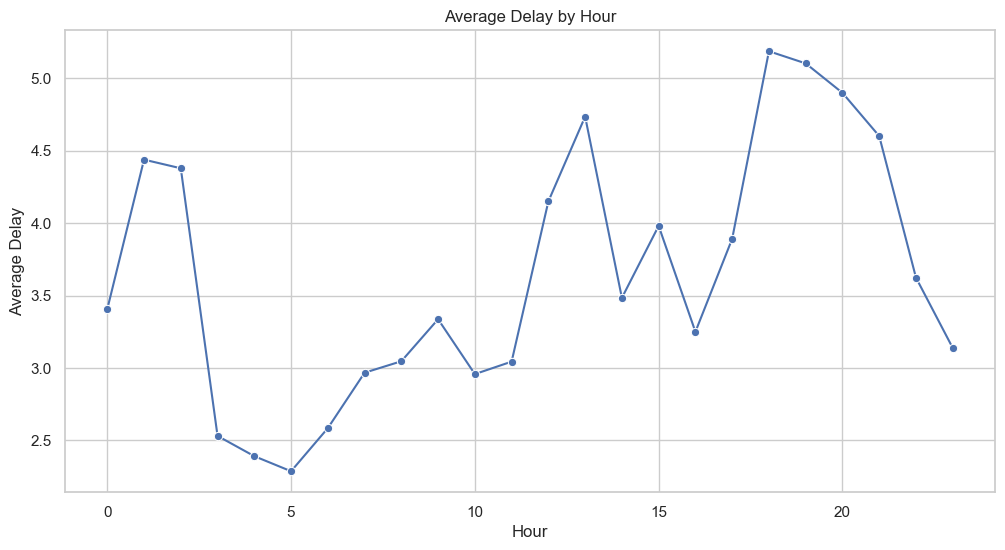

In [38]:
hour_delay = (
OTP_Copy
.groupby("hour")
["delay_minutes"]
.mean()
)
plt.figure(figsize=(12,6))
sns.lineplot(
x=hour_delay.index,
y=hour_delay.values,
marker="o"
)
plt.xlabel("Hour")
plt.ylabel("Average Delay")
plt.title("Average Delay by Hour")
plt.show()

**DAY OF WEEK**

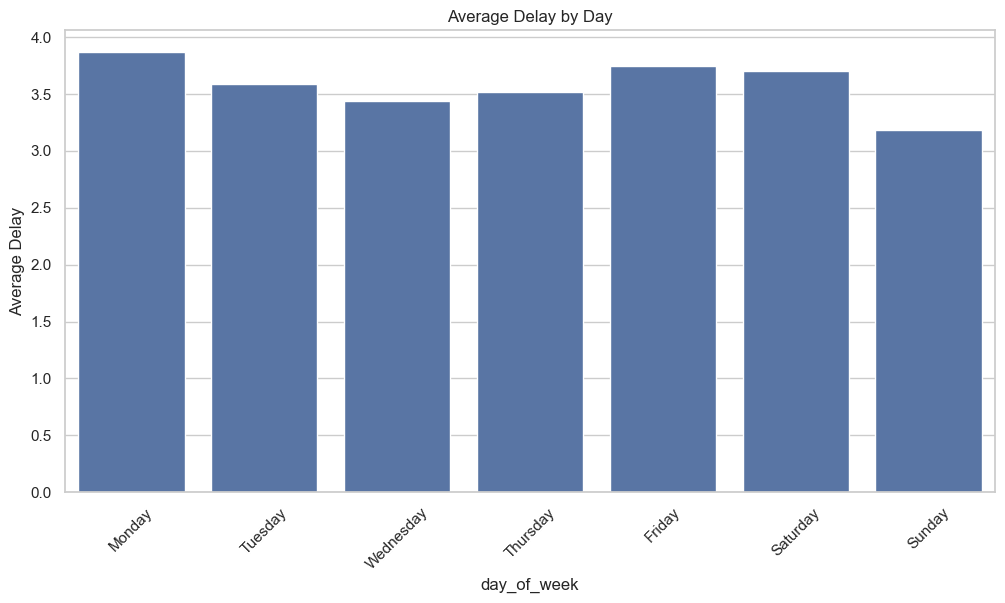

In [39]:
day_delay = (
OTP_Copy
.groupby("day_of_week")
["delay_minutes"]
.mean()
.reindex(
["Monday",
"Tuesday",
"Wednesday",
"Thursday",
"Friday",
"Saturday",
"Sunday"]
))

plt.figure(figsize=(12,6))
sns.barplot(
x=day_delay.index,
y=day_delay.values
)

plt.xticks(rotation=45)
plt.ylabel("Average Delay")
plt.title("Average Delay by Day")
plt.show()

**WEEKEND COMPARISON**

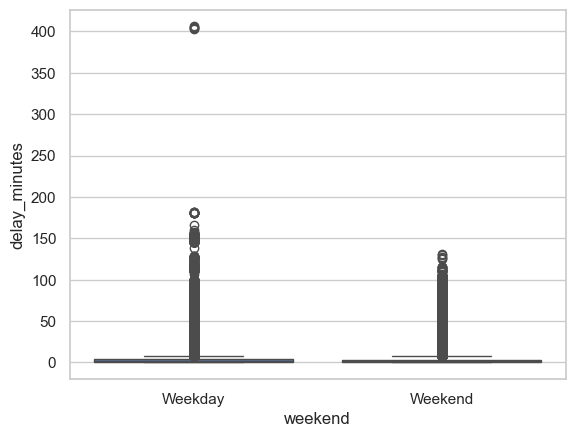

In [40]:
sns.boxplot(
data=OTP_Copy,
x="weekend",
y="delay_minutes"
)
plt.xticks(
[0,1],
["Weekday","Weekend"]
)
plt.show()

**MONTHLY TREND**

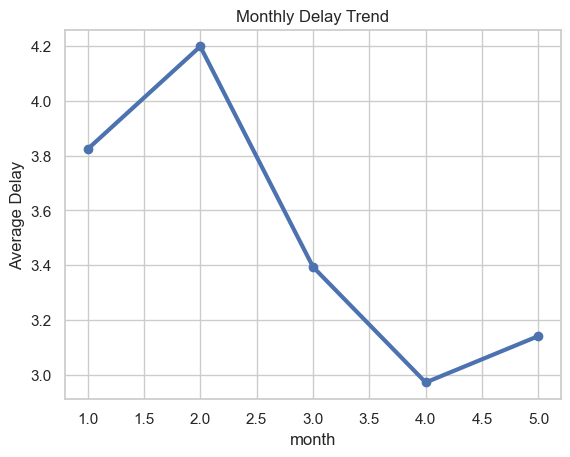

In [41]:
month_delay = (
OTP_Copy
.groupby("month")
["delay_minutes"]
.mean()

)

month_delay.plot(
marker="o",
linewidth=3
)

plt.ylabel("Average Delay")
plt.title("Monthly Delay Trend")
plt.show()

=====================================================================================================================

**RESEARCH QUESTION 2**

**OPERATOR COMPARISON**

The type column is used to compare delay behavior between NJ Transit and Amtrak. Grouping by operator allowed comparison of average delay, standard deviation, and record count.
*   Boxplots were also used to compare delay spread between the two operators.

This analysis supports the second research question by showing whether there are measurable differences in delay behavior between the two operators on the same corridor.

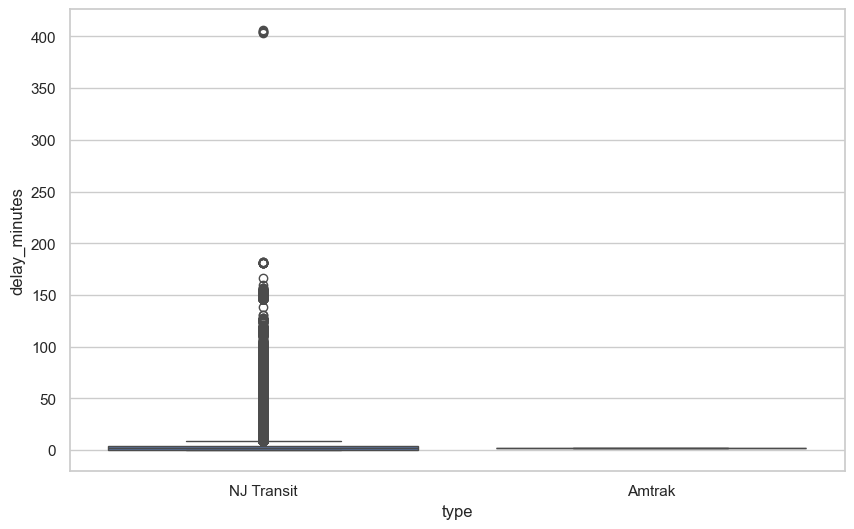

In [42]:
operator_delay = (
OTP_Copy
.groupby("type")
["delay_minutes"]
.agg(["mean","std","count"])
)
operator_delay

plt.figure(figsize=(10,6))
sns.boxplot(
data=OTP_Copy,
x="type",
y="delay_minutes"
)
plt.show()

=====================================================================================================================

**RESEARCH QUESTION 3**

Can machine learning predict future deays?


*   A time-based train-test split was used instead of a random split.
*   January to April data was used for training, while May data was used for testing. This is appropriate because the research question focuses on predicting future delays. Using earlier months for training and a later month for testing simulates a real-world forecasting scenario.

Three baseline models were used:
*   Linear Regression was used as the simplest baseline model. It assumes a linear relationship between features and delay minutes.
*   Support Vector Regression was used to test whether a more flexible model could capture non-linear delay patterns.
*   Random Forest Regressor was used because it can capture complex relationships between route, station, operator type, and time-based features.


***Interpretation***
The baseline machine learning models help determine whether historical train data has predictive value.
If the models produce low MAE and RMSE values, it suggests that historical route, station, operator, and time-based patterns can support delay prediction.

If R² is low, it means delays are difficult to fully predict using the available features alone, likely because train delays are affected by external factors not included in the dataset, such as weather, mechanical failures, signal issues, crew availability, passenger incidents, or infrastructure disruptions.

Therefore, machine learning can be used as an initial decision-support tool for predicting future delay risk, but the prediction quality depends heavily on the available features. The current model provides a strong baseline and can be improved by adding more operational variables, weather data, incident reports, train volume, and historical delay lag features.

In [45]:
#MACHINE LEARNING FEATURES

# ================================
# 1. Import required libraries
# ================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ================================
# 2. Sort data by date
# ================================
# Since we are predicting future delays, the dataset should be sorted by date.
# This makes sure older data is used for training and future data is used for testing.

df = OTP_Copy.sort_values("date").copy()


# ================================
# 3. Define ML features and target
# ================================
# These are the input variables used to predict delay_minutes.
#Station-level variables were excluded from some model runs 
#because one-hot encoding created a high-dimensional feature space, making tree-based models computationally expensive.

features = [
    #"from",
    #"to",
    "line",
    "type",
    "status",
    "hour",
    "day_of_week",
    "month",
    "weekend",
    "rush_hour"
]

target = "delay_minutes"


# ================================
# 4. Time-based train-test split
# ================================
# January to April data is used for training.
# May data is used for testing.
# This supports the research question: can historical data predict future delays?


train = df[df["month"] < 5]
test = df[df["month"] >= 5]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# Remove rows where target is missing
train_valid = y_train.notna()
test_valid = y_test.notna()

X_train = X_train[train_valid]
y_train = y_train[train_valid]

X_test = X_test[test_valid]
y_test = y_test[test_valid]

# ================================
# 5. Identify numeric and categorical columns
# ================================

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns


# ================================
# 6. Preprocessing for numeric variables
# ================================
# Missing numeric values are filled with median.
# StandardScaler is used because Linear Regression and SVR are sensitive to scale.

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


# ================================
# 7. Preprocessing for categorical variables
# ================================
# Missing categorical values are filled with the most frequent value.
# OneHotEncoder converts text categories into numeric format for ML models.
# handle_unknown="ignore" prevents errors if May has categories not seen in Jan-Apr.

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# ================================
# 8. Combine preprocessing steps
# ================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# ================================
# 9. Create models
# ================================

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    )
}

# ================================
# 10. Train and evaluate models
# ================================

results = []

for model_name, model in models.items():
    
    print(f"Training {model_name}...")
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    pipeline.fit(X_train, y_train)
    
    print(f"Predicting with {model_name}...")
    
    predictions = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

# ================================
# 11. Display model comparison
# ================================

results_df = pd.DataFrame(results)
results_df

Training Linear Regression...
Predicting with Linear Regression...
Training Random Forest...
Predicting with Random Forest...


,Model,MAE,RMSE,R2 Score
0,Linear Regression,3.205252,9.171396,0.095508
1,Random Forest,2.806961,7.895864,0.329601


**BASELINE MODEL**
The Linear Regression model: baseline regression model to predict the number of delay minutes. In the report, this model serves as a benchmark that can be compared against more advanced models like Gradient Boosting, or Random Forest.

**SVR was initially considered as a regression model; however, due to the high number of categorical features and one-hot encoded station variables, the model was computationally expensive and did not complete efficiently. Therefore, faster and more interpretable models such as Linear Regression and Random Forest were prioritized for baseline and comparative evaluation.**


**EVALUATION METRICES**
Tells how well the model predicts delay minutes.


*   Mean Absolute Error(MAE): The lower the better
*   Root Mean Squared Error (RMSE) : The lower the better. Root Mean Squared Error, or RMSE, also measures error in minutes, but it penalizes larger errors more strongly. This is useful because extreme train delays are operationally important.
*   R Square Score: Measures how much of the variation in delay is explained by the model. A value closer to 1 is better, while a value near 0 means the model does not explain much variation.


***LINEAR REGRESSION***:

MAE: The model's predictions differed from the actual delay by an average of approximately 3.20 minutes.

RMSE: Larger prediction errors average about 9.17 minutes.

R Square Score: The model explains approximately 10% of the variation in train delays.

It explained approximately 10% of the variation in train delay duration. An average prediction error of approximately 3 minutes indicates reasonable predictive capability using operational and temporal features alone.

***RANDOM FOREST***:

MAE: The model's predictions differed from the actual delay by an average of approximately 2.8 minutes.

RMSE: Larger prediction errors average about 7.89 minutes.

R Square Score: The model explains approximately 33% of the variation in train delays.

It explained approximately 33% of the variation in train delay duration. An average prediction error of approximately 2.8 minutes indicates reasonable predictive capability using operational and temporal features alone.

In [46]:
#GRADIENT BOOST FOR DELAY MINUTE PREDICTION
from sklearn.ensemble import GradientBoostingRegressor

# ================================
# Gradient Boosting Model
# ================================

gradient_boost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=50,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

# Train the model
print("Training Gradient Boosting model...")
gradient_boost_model.fit(X_train, y_train)

# Make predictions
print("Making predictions...")
gb_predictions = gradient_boost_model.predict(X_test)

# Evaluate model
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
gb_r2 = r2_score(y_test, gb_predictions)

print("Gradient Boosting Results")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R² Score:", gb_r2)

Training Gradient Boosting model...
Making predictions...
Gradient Boosting Results
MAE: 2.955845527108788
RMSE: 8.470995151842537
R² Score: 0.22838102821447115


***GRADIENT BOOST***:

MAE: The model's predictions differed from the actual delay by an average of approximately 2.9 minutes.

RMSE: Larger prediction errors average about 8.47 minutes.

R Square Score: The model explains approximately 22% of the variation in train delays.

The Gradient Boosting model achieved an average prediction error of approximately 3 minutes, indicating reasonable predictive accuracy for routine train operations. 
However, the larger RMSE demonstrates that the model struggles to accurately predict extreme delay events, which substantially increase prediction errors. 
Furthermore, the R² score of 22.8% indicates that the model explains only a modest proportion of the variability in train delays. This suggests that while temporal and operational variables such as line, train type, status, hour, day of week, and rush-hour indicators contribute to predicting delays, a significant amount of variation is driven by external operational factors that were not available in the dataset.

**DELAYED VS ON TIME CLASSIFICATION**

In [49]:
# Create clean binary target
OTP_Copy["otp_binary"] = (OTP_Copy["delay_minutes"] > 0).astype(int)

# Check result
print(OTP_Copy["otp_binary"].value_counts())

otp_binary
1    820804
0    144764
Name: count, dtype: int64


In [50]:
# Sort by date
df = OTP_Copy.sort_values("date").copy()

features_Class = [
    "from",
    "to",
    "line",
    "type",
    "status",
    "hour",
    "day_of_week",
    "month",
    "weekend",
    "rush_hour"
]

target_Class = "otp_binary"

# Time-based split
train = df[df["month"] < 5]
test = df[df["month"] >= 5]

X_train = train[features_Class]
y_train = train[target_Class]

X_test = test[features_Class]
y_test = test[target_Class]

In [51]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

log_predictions = logistic_model.predict(X_test)

print("Logistic Accuracy :", accuracy_score(y_test, log_predictions))
print("Logistic Precision:", precision_score(y_test, log_predictions))
print("Logistic Recall   :", recall_score(y_test, log_predictions))
print("Logistic F1 Score :", f1_score(y_test, log_predictions))

Logistic Accuracy : 0.8879815193823583
Logistic Precision: 0.8999144856763508
Logistic Recall   : 0.973691258826394
Logistic F1 Score : 0.9353503221958436


***LOGISTIC REGRESSION***
Accuracy = 88.80% means the percentage of trains that were correctly classified as either on time or delayed.
The Logistic Regression model correctly classified approximately 89 out of every 100 train observations.

Precision = Approximately 90% of the trains predicted as delayed were actually delayed.
This means the model produces relatively few false alarms.

Recall = The model successfully identified over 97% of all delayed trains.
This is particularly important in railway operations because failing to identify delays could negatively affect planning and operational response.

F1 Score = A score of 93.5% indicates that the model achieves an excellent balance between correctly identifying delayed trains while minimizing false delay predictions.

In [52]:
#RANDOM FOREST CLASSIFIER
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
print("Random Forest Accuracy :", accuracy_score(y_test, rf_predictions))
print("Random Forest Precision:", precision_score(y_test, rf_predictions))
print("Random Forest Recall   :", recall_score(y_test, rf_predictions))
print("Random Forest F1 Score :", f1_score(y_test, rf_predictions))

Random Forest Accuracy : 0.8961073172708667
Random Forest Precision: 0.9004523374481929
Random Forest Recall   : 0.9839420501582664
Random Forest F1 Score : 0.9403476520686928


***RANDOM FOREST***
Random Forest slightly outperformed Logistic Regression across nearly every metric.
* Highest Accuracy (Logistic: 0.8879, Random Forest: 0.8910)
* Highest Recall (Logistic: 0.9736, Random Forest: 0.9839)
* Highest F1 Score (Logistic: 0.9353, Random Forest: 0.9403)
The Recall of 98.39% means the model detected almost every delayed train.
Operationally, this is valuable because very few delayed trains would be missed.

In [53]:
#GRADIENT BOOSTING CLASSIFIER
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=50,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

print("Gradient Boost Accuracy :", accuracy_score(y_test, gb_predictions))
print("Gradient Boost Precision:", precision_score(y_test, gb_predictions))
print("Gradient Boost Recall   :", recall_score(y_test, gb_predictions))
print("Gradient Boost F1 Score :", f1_score(y_test, gb_predictions))

Gradient Boost Accuracy : 0.8956513809803643
Gradient Boost Precision: 0.9074697975157393
Gradient Boost Recall   : 0.9739225712198685
Gradient Boost F1 Score : 0.9395225931471858


***GRADIENT BOOST***
Gradient Boosting achieved nearly identical performance to Random Forest.
Its main strength is Precision.
A Precision of 90.75% means when the model predicts a delay, it is slightly more likely to be correct than the other models.
This makes it useful when reducing false delay predictions is particularly important.

***CONFUSION MATRIC***


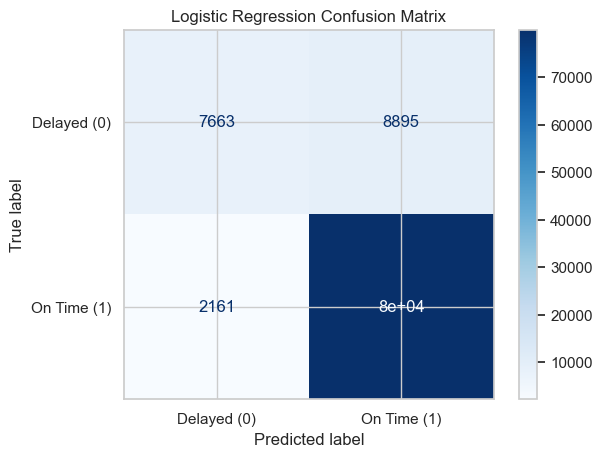

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, log_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Delayed (0)", "On Time (1)"]
)

disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

(where 8e+04 is scientific notation for approximately 80,000)

True Negatives (7,663)
These are trains that were actually delayed, and the model correctly predicted them as delayed.

False Positives (8,895)
These are trains that were actually delayed, but the model predicted they would be on time.
Operationally, these are the most concerning mistakes because passengers and operations would expect an on-time service when a delay actually occurs.

False Negatives (2,161)
These are trains that were actually on time, but the model predicted they would be delayed.
These represent false alarms. They may lead to unnecessary operational responses but are generally less serious than missing an actual delay.

True Positives (≈80,000)
These are trains that were actually on time, and the model correctly predicted them as on time.


Delayed trains:
7,663 + 8,895 = 16,558

On-time trains:
2,161 + 80,000 ≈ 82,161

The dataset appears to contain far more on-time trains than delayed trains that causes class imbalance.
Because most trains are on time, a model can achieve a high overall Accuracy by predicting on-time correctly most of the time.

***the model is excellent at identifying on-time trains.***